第10章

In [2]:
import pandas as pd
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\bike.tsv',sep='\t')
display(df.head(3))

,dteday,holiday,weekday,workingday,weather_id,cnt
0,2011-01-01,0,6,0,2,985
1,2011-01-02,0,0,0,2,801
2,2011-01-03,0,1,1,1,1349


In [3]:
weather=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\weather.csv',encoding='shift-jis')
weather

,weather_id,weather
0,1,晴れ
1,2,曇り
2,3,雨


In [ ]:
temp=pd.read_json(r'C:\Users\natsu\Desktop\machine_learning\datafiles\temp.json')
temp.T

,atemp,dteday,hum,temp,windspeed
0,0.363625,2011-01-01,0.805833,0.344167,0.160446
1,0.353739,2011-01-02,0.696087,0.363478,0.248539
2,0.189405,2011-01-03,0.437273,0.196364,0.248309
3,0.212122,2011-01-04,0.590435,0.2,0.160296
4,0.22927,2011-01-05,0.436957,0.226957,0.1869
...,...,...,...,...,...
725,0.226642,2012-12-27,0.652917,0.254167,0.350133
726,0.255046,2012-12-28,0.59,0.253333,0.155471
727,0.2424,2012-12-29,0.752917,0.253333,0.124383
728,0.2317,2012-12-30,0.483333,0.255833,0.350754


In [ ]:
df2=df.merge(weather,how='inner',on='weather_id')
df2=df2.sort_values(by='dteday')
df2.head(2)

,dteday,holiday,weekday,workingday,weather_id,cnt,weather
0,2011-01-01,0,6,0,2,985,曇り
1,2011-01-02,0,0,0,2,801,曇り


In [8]:
df2.groupby('weather')['cnt'].mean()

weather
晴れ    4876.786177
曇り    4052.672065
雨     1803.285714
Name: cnt, dtype: float64

In [9]:
temp=temp.T
temp.loc[199:201]

,atemp,dteday,hum,temp,windspeed
199,0.747479,2011-07-19,0.650417,0.776667,0.1306
200,0.826371,2011-07-21,0.69125,0.815,0.222021
201,None,2011-07-22,0.580417,0.848333,0.1331


In [10]:
df2[df2['dteday']=='2011-07-20']

,dteday,holiday,weekday,workingday,weather_id,cnt,weather
200,2011-07-20,0,3,1,1,4332,晴れ


In [12]:
df3=df2.merge(temp,how='left',on='dteday')
df3[df3['dteday']=='2011-07-20']

,dteday,holiday,weekday,workingday,weather_id,cnt,weather,atemp,hum,temp,windspeed
200,2011-07-20,0,3,1,1,4332,晴れ,NaN,NaN,NaN,NaN


<Axes: >

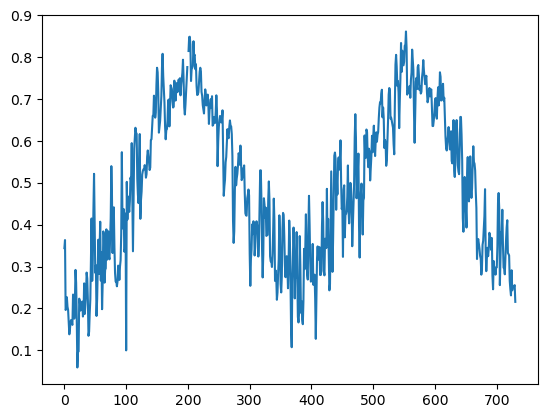

In [13]:
df3['temp'].plot(kind='line')

<Axes: >

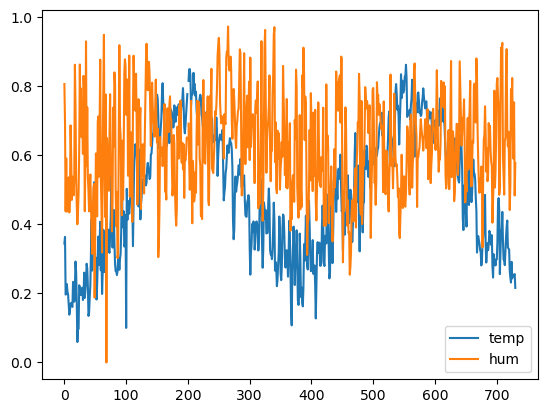

In [14]:
df3[['temp','hum']].plot(kind='line')

<Axes: ylabel='Frequency'>

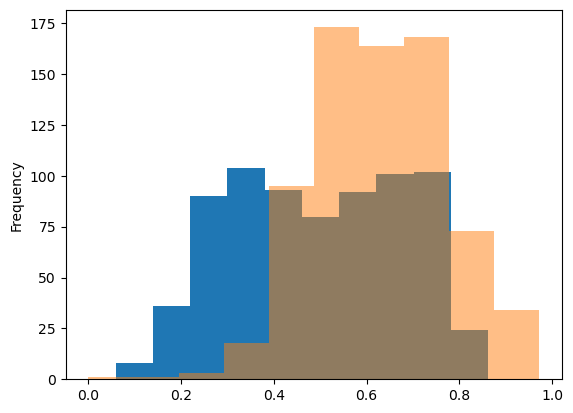

In [15]:
df3['temp'].plot(kind='hist')
df3['hum'].plot(kind='hist',alpha=0.5)

<Axes: >

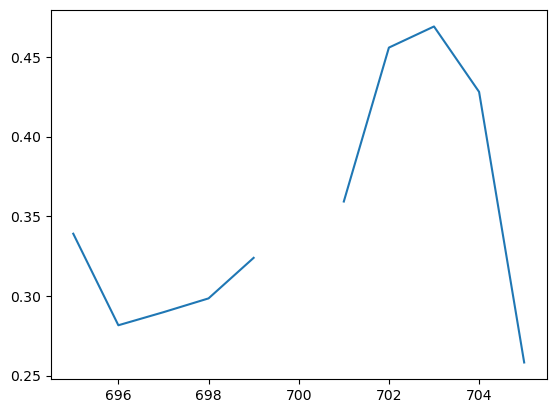

In [16]:
df3['atemp'].loc[695:705].plot(kind='line')

<Axes: >

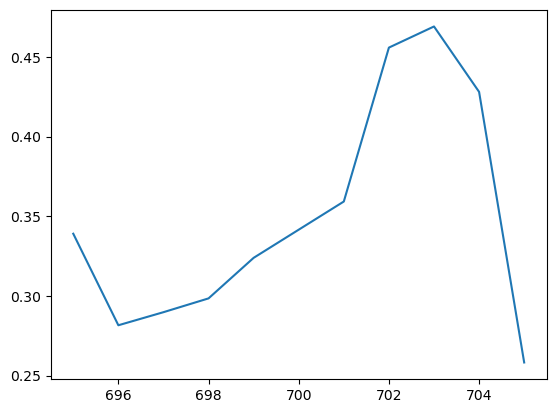

In [18]:
df3['atemp']=df3['atemp'].astype(float)
df3['atemp']=df3['atemp'].interpolate()
df3.loc[695:705,'atemp'].plot()

In [19]:
iris_df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\iris.csv') #欠損を含むデータ
non_df=iris_df.dropna() #欠損値を含む行を削除
from sklearn.linear_model import LinearRegression
x=non_df.loc[:,'がく片幅':'花弁幅']
t=non_df['がく片長さ']
model=LinearRegression()
model.fit(x,t) #欠損値予測モデルの作成


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
condition=iris_df['がく片長さ'].isnull()   #欠損行の抜き出し
non_data=iris_df.loc[condition]

x=non_data.loc[:,'がく片幅':'花弁幅']
pred=model.predict(x)

iris_df.loc[condition,'がく片長さ']=pred

In [24]:
from sklearn.covariance import MinCovDet

df4=df3.loc[:,'atemp':'windspeed']
df4=df4.dropna()

mcd=MinCovDet(random_state=0,support_fraction=0.7)
mcd.fit(df4)

distance=mcd.mahalanobis(df4)
distance

array([5.28685919e+00, 2.93958299e+00, 1.08873903e+01, 3.91777267e+00,
       5.83743181e+00, 6.85979161e+00, 4.57807325e+00, 1.12294313e+01,
       3.07879561e+01, 1.07350024e+01, 4.93484073e+00, 1.74968772e+01,
       1.87331329e+01, 5.32729180e+00, 3.61541859e+00, 4.80173345e+00,
       8.21213444e+00, 6.79836643e+00, 2.87299048e+00, 5.25717722e+00,
       2.34832751e+01, 1.17927956e+01, 1.49622820e+01, 8.00089913e+00,
       3.82116490e+00, 2.10012092e+01, 4.47041230e+00, 5.45651259e+00,
       3.90883119e+00, 7.18467288e+00, 6.26114495e+00, 1.11698504e+01,
       8.91683812e+00, 1.31862666e+01, 3.78816752e+00, 9.40980352e+00,
       2.37017046e+00, 9.05455392e+00, 2.15907661e+01, 8.24295918e+00,
       9.58859635e+00, 5.84834138e+00, 3.26204050e+00, 4.28450181e+00,
       1.48613074e+01, 1.14032754e+01, 4.13782899e+00, 1.84042916e+00,
       4.70582846e+00, 3.26061846e+01, 5.97687800e+00, 1.00266113e+01,
       6.60674933e+00, 8.23738671e+00, 4.97949164e+00, 9.40472950e+00,
      

<Axes: >

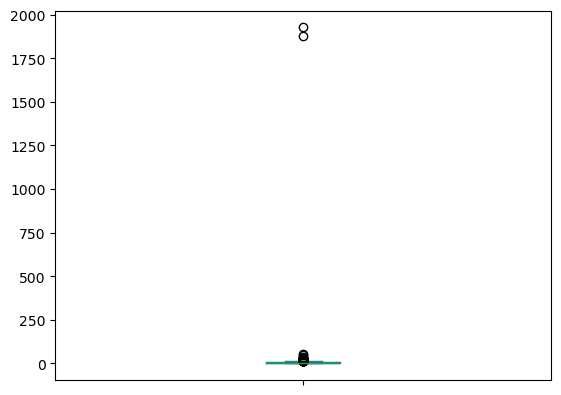

In [ ]:
distance=pd.Series(distance)   
distance.plot(kind='box')